## **DAY 10 — Hyperparameter Tuning + Cross Validation + ML Pipelines**

### **PART 1: Deep Dive: What are Hyperparameters?**

Hyperparameters are the **external settings** that define how a model learns. They are set manually **before** training begins. Finding the right combination is key to model performance.

#### **Key Random Forest Hyperparameters:**
- **`n_estimators`**: The number of decision trees in the forest. Generally, more trees improve accuracy but increase computation time.
- **`max_depth`**: The maximum depth of each tree. High depth can capture complex patterns but risks **overfitting** (memorizing noise).
- **`min_samples_split`**: The minimum number of samples required to split an internal node.
- **`random_state`**: Ensures the results are reproducible by controlling the randomness.

In [17]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split

# 1. Create a sample DataFrame
X_raw, y_raw = make_classification(n_samples=1000, n_features=10, n_informative=8, random_state=42)
feature_names = [f'feature_{i}' for i in range(10)]
df = pd.DataFrame(X_raw, columns=feature_names)
df['target'] = y_raw

print("Sample DataFrame (Top 5 rows):")
display(df.head())

# 2. Prepare data for modeling
X = df.drop('target', axis=1)
y = df['target']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Compare models with different hyperparameters
configs = [
    {"n_estimators": 10, "max_depth": 2, "name": "Simple (Underfit?)"},
    {"n_estimators": 100, "max_depth": 20, "name": "Complex (Overfit?)"}
]

results = []
for cfg in configs:
    rf = RandomForestClassifier(n_estimators=cfg['n_estimators'], max_depth=cfg['max_depth'], random_state=42)
    rf.fit(X_train, y_train)

    results.append({
        "Model Config": cfg['name'],
        "n_estimators": cfg['n_estimators'],
        "max_depth": cfg['max_depth'],
        "Train Accuracy": f"{rf.score(X_train, y_train):.2%}",
        "Test Accuracy": f"{rf.score(X_test, y_test):.2%}"
    })

display(pd.DataFrame(results))

Sample DataFrame (Top 5 rows):


,feature_0,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,target
0,-0.224515,-0.648598,2.805591,0.569525,2.676771,0.685312,0.306675,1.147291,-2.145905,2.477879,1
1,1.038548,-1.316803,2.303387,1.233593,4.972675,1.086905,-3.548788,0.342810,-0.469005,2.787109,1
2,1.148988,1.794382,2.835693,-1.114858,-1.247120,-1.899268,-0.381470,0.837209,0.163223,-0.997959,1
3,-1.177318,2.420294,-0.363514,-1.086646,-2.824750,-2.722123,-0.225266,0.515079,-3.317272,-2.801517,1
4,1.346717,0.089373,2.056613,-0.428365,0.285387,1.140716,0.721945,1.110152,2.426608,0.880496,0


,Model Config,n_estimators,max_depth,Train Accuracy,Test Accuracy
0,Simple (Underfit?),10,2,74.38%,70.00%
1,Complex (Overfit?),100,20,100.00%,87.00%


### **Code Breakdown**

1. **DataFrame Creation**: We used `make_classification` to create raw numbers and `pd.DataFrame` to organize them into a table with named features.
2. **Training vs. Testing**: We split the data so the model learns on one part and is tested on a part it has never seen. This reveals if the hyperparameters are good.
3. **Comparing Hyperparameters**:
    * **Simple Model**: With low `n_estimators` (10) and `max_depth` (2), the model is limited. It might not learn enough (Underfitting).
    * **Complex Model**: With high `n_estimators` (100) and `max_depth` (20), the model is powerful. It might learn the noise in the training data too well (Overfitting).

---
<br>

## **PART 2 — GridSearchCV**

Manually testing every combination of hyperparameters is slow and inefficient. **GridSearchCV** automates this by:
1.  **Grid Search**: Trying every combination in a 'grid' of parameters.
2.  **Cross-Validation (CV)**: Splitting the training data into 'folds' to ensure the parameters work well across different subsets of data, not just one split.

In [5]:
from sklearn.model_selection import GridSearchCV

# 1. Initialize the model
rf = RandomForestClassifier(random_state=42)

# 2. Define the 'Grid' of parameters to test
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [5, 10, 15],
    'min_samples_split': [2, 5]
}

# 3. Setup GridSearchCV
# cv=5 means 5-fold cross-validation
grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, cv=5, n_jobs=-1, verbose=1)

# 4. Run the search
print("Searching for the best hyperparameters...")
grid_search.fit(X_train, y_train)

# 5. Results
print(f"\nBest Parameters: {grid_search.best_params_}")

# Evaluate the best model found by the search
best_rf = grid_search.best_estimator_
train_acc = best_rf.score(X_train, y_train)
test_acc = best_rf.score(X_test, y_test)

print(f"Best Model Train Accuracy: {train_acc:.2%}")
print(f"Best Model Test Accuracy: {test_acc:.2%}")

Searching for the best hyperparameters...
Fitting 5 folds for each of 18 candidates, totalling 90 fits

Best Parameters: {'max_depth': 15, 'min_samples_split': 2, 'n_estimators': 50}
Best Model Train Accuracy: 100.00%
Best Model Test Accuracy: 87.00%


---
<br>

## **PART 3 — Cross Validation**

Cross-validation is the gold standard for evaluating model performance. Instead of one split, we use **K-Fold Cross Validation**:
1. The data is split into **K** equal parts (folds).
2. The model is trained **K** times.
3. Each time, a different fold is used as the test set (validation set), and the remaining folds are used for training.

This gives us a list of scores, allowing us to see the **average performance** and the **stability** (standard deviation) of the model.

In [6]:
from sklearn.model_selection import cross_val_score
import numpy as np

# We will use the 'best_rf' model found in the previous step
# We use the full X and y because CV handles the splitting internally
scores = cross_val_score(best_rf, X, y, cv=5)

print("--- K-Fold Results (K=5) ---")
print(f"Scores per fold: {scores}")
print(f"Average Accuracy: {scores.mean():.2%}")
print(f"Standard Deviation: {scores.std():.4f}")

if scores.std() < 0.05:
    print("\nInterpretation: The model is stable across different data splits.")
else:
    print("\nInterpretation: The high variance suggests the model might be sensitive to specific data samples.")

--- K-Fold Results (K=5) ---
Scores per fold: [0.86  0.885 0.89  0.915 0.86 ]
Average Accuracy: 88.20%
Standard Deviation: 0.0206

Interpretation: The model is stable across different data splits.


---
<br>

## **PART 4 — Bias vs. Variance**

This is the central struggle in Machine Learning. Every time you tune a hyperparameter, you are moving the needle between Bias and Variance.

### **The Comparison Table**

| Feature | **High Bias (Underfitting)** | **High Variance (Overfitting)** | **The Sweet Spot** |
| :--- | :--- | :--- | :--- |
| **Model Complexity** | Low (too simple) | High (too complex) | Just right |
| **Training Error** | High | Very Low | Low |
| **Test Error** | High | High | Low |
| **Analogy** | A student who refuses to learn the details. | A student who memorizes the textbook but fails the exam. | A student who learns the concepts. |

### **Visualizing the Tradeoff**
In our Random Forest:
- Decreasing `max_depth` increases **Bias**.
- Increasing `max_depth` increases **Variance**.

---
<br>

## **PART 5 — ML Pipelines**

Professional ML systems use **Pipelines** to automate the workflow. Instead of applying transformations (like scaling) manually to the training and testing sets separately, a pipeline ensures the same steps are applied consistently.

### **Benefits:**
1. **Prevents Data Leakage**: Transformations are fitted only on training data.
2. **Cleaner Code**: One `fit()` and `predict()` call for the entire workflow.
3. **Easy Deployment**: You can export the entire pipeline as a single file.

In [7]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier

# 1. Define the Pipeline steps
# Each step is a tuple: ("name", transformer/estimator)
pipe = Pipeline([
    ("scaler", StandardScaler()), # Scales features to have mean=0 and variance=1
    ("model", RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42))
])

# 2. Train the entire pipeline
# The pipeline scales the data FIRST, then fits the model
pipe.fit(X_train, y_train)

# 3. Evaluate
# The pipeline automatically applies the SAME scaling logic to X_test
score = pipe.score(X_test, y_test)
print(f"Pipeline Test Accuracy: {score:.2%}")

Pipeline Test Accuracy: 86.00%


---
<br>

## **PART 6 — RandomizedSearchCV**

**GridSearchCV** tests every single possible combination, which is computationally expensive. **RandomizedSearchCV** instead samples a fixed number of parameter settings from specified distributions.

### **Why use it?**
- **Efficiency**: Much faster than GridSearch for large parameter spaces.
- **Control**: You can define exactly how many iterations (`n_iter`) you want to run.
- **Performance**: Research shows it often finds a nearly-optimal solution much quicker than an exhaustive search.

In [8]:
from sklearn.model_selection import RandomizedSearchCV

# 1. Define a wider range of parameters
param_dist = {
    'n_estimators': [50, 100, 200, 300, 400, 500],
    'max_depth': [None, 10, 20, 30, 40, 50],
    'min_samples_split': [2, 5, 10],
    'bootstrap': [True, False]
}

# 2. Setup RandomizedSearchCV
# n_iter=10 means it will pick 10 random combinations to try
random_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=10,
    cv=5,
    random_state=42,
    n_jobs=-1
)

# 3. Run the search
print("Running Randomized Search...")
random_search.fit(X_train, y_train)

# 4. Results
print(f"Best Parameters Found: {random_search.best_params_}")
print(f"Best Cross-Val Score: {random_search.best_score_:.2%}")

Running Randomized Search...
Best Parameters Found: {'n_estimators': 300, 'min_samples_split': 2, 'max_depth': 50, 'bootstrap': False}
Best Cross-Val Score: 89.25%


---
<br>

## **PART 7 — Evaluation Metrics Revisited**

While we've used Accuracy so far, professional engineers look at a variety of metrics to determine if a model is truly 'good' for a specific business problem.

### **1. Classification Metrics**
| Metric | Use Case |
| :--- | :--- |
| **Accuracy** | Good for balanced classes. Overall % of correct guesses. |
| **Precision** | Use when the cost of a **False Positive** is high (e.g., Spam detection). |
| **Recall** | Use when the cost of a **False Negative** is high (e.g., Cancer detection). |
| **F1-Score** | The harmonic mean of Precision and Recall. Best for imbalanced datasets. |

### **2. Regression Metrics**
| Metric | Use Case |
| :--- | :--- |
| **MAE (Mean Absolute Error)** | Easy to interpret; average error in units of the target. |
| **RMSE (Root Mean Squared Error)** | Penalizes large errors more heavily than MAE. |
| **R² Score** | Measures the proportion of variance explained by the model (0 to 1). |

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.84      0.86       106
           1       0.83      0.86      0.84        94

    accuracy                           0.85       200
   macro avg       0.85      0.85      0.85       200
weighted avg       0.85      0.85      0.85       200



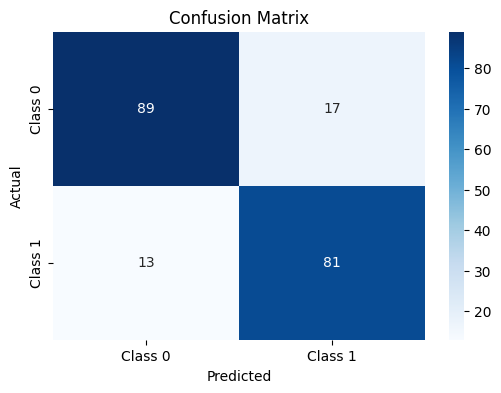

In [9]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Generate predictions using our best model
y_pred = random_search.predict(X_test)

# 1. Detailed Classification Report
print("Classification Report:")
print(classification_report(y_test, y_pred))

# 2. Confusion Matrix Visualization
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Class 0', 'Class 1'], yticklabels=['Class 0', 'Class 1'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

---
<br>

## **PART 8 — Full Professional Workflow**

This is how a Senior ML Engineer would structure the code. We wrap the scaler and the model into a **Pipeline**, and then we pass that entire pipeline into **GridSearchCV**. This ensures that during cross-validation, the scaling is calculated correctly for every single fold (preventing data leakage).

### **PART 8 (Revised): Step-by-Step Professional Workflow**

#### **Step 1: Create a New Dataset**
We will create a small `pandas` DataFrame representing customers with different ages and incomes.

In [10]:
import pandas as pd
from sklearn.model_selection import train_test_split

# Sample data: Age, Income, and whether they Purchased (1) or not (0)
data = {
    "Age": [22, 25, 47, 35, 40, 28, 32, 45, 23, 38, 50, 55, 60, 21, 31],
    "Income": [25000, 30000, 95000, 50000, 70000, 35000, 45000, 80000, 22000, 65000, 110000, 120000, 150000, 18000, 48000],
    "Purchased": [0, 0, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 0]
}

df_new = pd.DataFrame(data)

# Split into Features (X) and Target (y)
X_new = df_new[["Age", "Income"]]
y_new = df_new["Purchased"]

# Train/Test Split
X_train_new, X_test_new, y_train_new, y_test_new = train_test_split(
    X_new, y_new, test_size=0.2, random_state=42
)

display(df_new.head())

,Age,Income,Purchased
0,22,25000,0
1,25,30000,0
2,47,95000,1
3,35,50000,1
4,40,70000,1


#### **Step 2: Define the Pipeline and Parameter Grid**
We use a `Pipeline` to ensure that scaling and the model are treated as a single unit.

In [11]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

# 1. Bundle scaling and the classifier
pro_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('rf', RandomForestClassifier(random_state=42))
])

# 2. Define parameters to tune
# Use the prefix 'rf__' to tell GridSearchCV to look inside the pipeline at the 'rf' step
pro_params = {
    'rf__n_estimators': [50, 100],
    'rf__max_depth': [3, 5, 10]
}

#### **Step 3: Run GridSearchCV and Evaluate**

In [12]:
# 3. Execute Search
grid_pro = GridSearchCV(pro_pipeline, pro_params, cv=2) # Using cv=2 due to small dataset size
grid_pro.fit(X_train_new, y_train_new)

# 4. Results
print(f"Best Parameters: {grid_pro.best_params_}")
print(f"Accuracy on New Test Set: {grid_pro.score(X_test_new, y_test_new):.2%}")

Best Parameters: {'rf__max_depth': 3, 'rf__n_estimators': 50}
Accuracy on New Test Set: 100.00%


---
<br>

## **PART 9 — Real Industry Understanding**

### **What Real ML Engineers Do**
*   **Feature Engineering**: Spend 80% of their time cleaning and creating new variables.
*   **Automated Pipelines**: Never manually scale data; always use `sklearn.pipeline`.
*   **Hyperparameter Tuning**: Use `RandomizedSearchCV` or `Bayesian Optimization` for large models to save time.
*   **Monitoring**: Once deployed, they track if the model's accuracy drops over time (Model Drift).

### **Finance AI Connection**
In high-frequency trading or risk management:
1.  **Cross-Validation** prevents the model from 'memorizing' a specific market cycle that might never happen again.
2.  **Pipelines** ensure that when a new trade comes in, it is scaled exactly the same way the historical data was.
3.  **Precision/Recall** is critical: A False Positive (buying a bad stock) might be more expensive than a False Negative (missing a good trade).

---
<br>

## **PRATICE SET 1**

### **CHALLENGE: Professional Credit Scoring Model**

**Scenario:** You are an ML Engineer at a Fintech company. You need to build a stable, scaled, and optimized model to predict loan approvals.

**Your Task:**
1.  Run the cell below to generate the `df_practice` dataset.
2.  Create a `Pipeline` containing `StandardScaler` and `RandomForestClassifier`.
3.  Use `GridSearchCV` to test:
    *   `n_estimators`: [100, 200]
    *   `max_depth`: [5, 10]
4.  Print the final accuracy and the classification report.

In [13]:
import numpy as np
import pandas as pd
from sklearn.datasets import make_classification

# --- Step 1: Generate Professional Practice Data ---
# Simulating 500 customers with Credit Score, Debt-to-Income, and Savings
X_p, y_p = make_classification(
    n_samples=500,
    n_features=3,
    n_informative=3,
    n_redundant=0,
    random_state=7
)

df_practice = pd.DataFrame(X_p, columns=['Credit_Score', 'Debt_Ratio', 'Savings_Account'])
df_practice['Loan_Approved'] = y_p

print("Practice Dataset Generated (First 5 rows):")
display(df_practice.head())

Practice Dataset Generated (First 5 rows):


,Credit_Score,Debt_Ratio,Savings_Account,Loan_Approved
0,0.873824,-0.197805,0.111433,1
1,-0.963698,0.150849,-0.946550,0
2,-1.087585,0.173253,-1.336077,1
3,-3.196757,0.039153,-1.056249,0
4,1.224909,1.270561,-0.827489,1


In [14]:
#STEP 1: IMPORT LIBRARIES
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report

In [15]:
#STEP 2: SPLIT
X_l = df_practice.drop(columns=['Loan_Approved'])
y_l = df_practice['Loan_Approved']

In [16]:
from sklearn.model_selection import train_test_split

# Ensure features and target are defined (Step 2 logic)
X_l = df_practice.drop(columns=['Loan_Approved'])
y_l = df_practice['Loan_Approved']

# Step 3: Split into 80% training and 20% testing
X_train_l, X_test_l, y_train_l, y_test_l = train_test_split(
    X_l, y_l, test_size=0.2, random_state=42
)

print("Data successfully split into training and testing sets.")

Data successfully split into training and testing sets.


In [20]:
#STEP 3: PIPELINE

pr_pipeline = Pipeline([
    ('scale', StandardScaler()),
    ('RF', RandomForestClassifier(random_state=42))
])

In [22]:
#STEP 4: PARAMS

prams = {
    'RF__n_estimators': [100, 200], # Added missing comma and double underscore
    'RF__max_depth': [5, 10]
}

#EXECUTE SEARCH
grid_pra = GridSearchCV(pr_pipeline, prams, cv=2)
grid_pra.fit(X_train_l, y_train_l)

#RESULTS
print(f"Best Parameters: {grid_pra.best_params_}")
print(f"Accuracy on New Test Set: {grid_pra.score(X_test_l, y_test_l):.2%}")

Best Parameters: {'RF__max_depth': 10, 'RF__n_estimators': 200}
Accuracy on New Test Set: 86.00%


In [23]:
# FINAL STEP: Classification Report
y_pred_l = grid_pra.predict(X_test_l)

print("Detailed Classification Report:")
print(classification_report(y_test_l, y_pred_l))

Detailed Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.80      0.84        45
           1       0.85      0.91      0.88        55

    accuracy                           0.86       100
   macro avg       0.86      0.85      0.86       100
weighted avg       0.86      0.86      0.86       100



## **PRATICE SET 2**

In [25]:
import pandas as pd
import numpy as np
from sklearn.datasets import make_classification

# --- Step 1: Generate Stock Market Practice Data ---
# Features: Volatility_Index, Relative_Volume, Moving_Average_Diff
X_stock, y_stock = make_classification(
    n_samples=600,
    n_features=3,
    n_informative=3,
    n_redundant=0,
    random_state=42
)

df_stock = pd.DataFrame(X_stock, columns=['Volatility', 'Volume_Score', 'MA_Trend'])
df_stock['Signal'] = y_stock # 1 = Buy, 0 = Sell

print("New Practice Dataset: Stock Market Signals")
display(df_stock.head())

New Practice Dataset: Stock Market Signals


,Volatility,Volume_Score,MA_Trend,Signal
0,2.136841,0.772571,1.713832,1
1,-3.835809,-0.298383,-0.246453,0
2,0.388507,1.890223,-0.003262,1
3,0.804133,-0.805520,0.925741,1
4,0.658653,2.578791,1.275474,1


In [26]:
# STEP 2 & 3: Split Data and Setup Search
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

# 1. Prepare X and y
X_s = df_stock.drop(columns=['Signal'])
y_s = df_stock['Signal']

# 2. Split
X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(X_s, y_s, test_size=0.2, random_state=42)

# 3. Create Pipeline
stock_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('rf', RandomForestClassifier(random_state=42))
])

# 4. Define Grid
stock_params = {
    'rf__n_estimators': [100, 300],
    'rf__max_depth': [None, 5, 10],
    'rf__min_samples_split': [2, 5]
}

# 5. Execute Search
grid_stock = GridSearchCV(stock_pipe, stock_params, cv=3)
grid_stock.fit(X_train_s, y_train_s)

print(f"Best Score: {grid_stock.best_score_:.2%}")
print(f"Best Params: {grid_stock.best_params_}")

Best Score: 92.08%
Best Params: {'rf__max_depth': 10, 'rf__min_samples_split': 2, 'rf__n_estimators': 300}


In [27]:
# FINAL STEP: Evaluate on Test Set
from sklearn.metrics import classification_report

y_pred_s = grid_stock.predict(X_test_s)

print("--- Stock Market Model: Final Evaluation ---")
print(classification_report(y_test_s, y_pred_s))

--- Stock Market Model: Final Evaluation ---
              precision    recall  f1-score   support

           0       0.86      0.94      0.90        54
           1       0.95      0.88      0.91        66

    accuracy                           0.91       120
   macro avg       0.91      0.91      0.91       120
weighted avg       0.91      0.91      0.91       120

